# Step 1: Clean and preprocess the dataset

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

In [9]:
#loading dataset

df = pd.read_csv("D:\\Data Science & Analytics Internship\\Phase 2\\Task 9 Loan Default Risk with Business Cost Optimization\\application_train.csv")

print("Shape:", df.shape)
df.head()

Shape: (307511, 122)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [12]:
df.info()
df.isnull().sum().sort_values(ascending=False).head(20)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB


COMMONAREA_MEDI             214865
COMMONAREA_AVG              214865
COMMONAREA_MODE             214865
NONLIVINGAPARTMENTS_MODE    213514
NONLIVINGAPARTMENTS_AVG     213514
NONLIVINGAPARTMENTS_MEDI    213514
FONDKAPREMONT_MODE          210295
LIVINGAPARTMENTS_MODE       210199
LIVINGAPARTMENTS_AVG        210199
LIVINGAPARTMENTS_MEDI       210199
FLOORSMIN_AVG               208642
FLOORSMIN_MODE              208642
FLOORSMIN_MEDI              208642
YEARS_BUILD_MEDI            204488
YEARS_BUILD_MODE            204488
YEARS_BUILD_AVG             204488
OWN_CAR_AGE                 202929
LANDAREA_MEDI               182590
LANDAREA_MODE               182590
LANDAREA_AVG                182590
dtype: int64

In [13]:
features = [
    'TARGET',
    'AMT_INCOME_TOTAL',
    'AMT_CREDIT',
    'AMT_ANNUITY',
    'AMT_GOODS_PRICE',
    'DAYS_BIRTH',
    'DAYS_EMPLOYED',
    'CODE_GENDER',
    'NAME_INCOME_TYPE',
    'NAME_EDUCATION_TYPE'
]

df = df[features]

In [14]:
num_cols = df.select_dtypes(include=['int64','float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

# Numeric imputation
num_imputer = SimpleImputer(strategy='median')
df[num_cols] = num_imputer.fit_transform(df[num_cols])

# Categorical imputation
cat_imputer = SimpleImputer(strategy='most_frequent')
df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])

In [15]:
le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

In [17]:
X = df.drop("TARGET", axis=1)
y = df["TARGET"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Step 2: Train binary classification model

In [18]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred_prob = model.predict_proba(X_test)[:,1]

In [19]:
y_pred_default = (y_pred_prob >= 0.5).astype(int)

print(confusion_matrix(y_test, y_pred_default))
print(classification_report(y_test, y_pred_default))
print("ROC AUC:", roc_auc_score(y_test, y_pred_prob))

[[56553     1]
 [ 4949     0]]
              precision    recall  f1-score   support

         0.0       0.92      1.00      0.96     56554
         1.0       0.00      0.00      0.00      4949

    accuracy                           0.92     61503
   macro avg       0.46      0.50      0.48     61503
weighted avg       0.85      0.92      0.88     61503

ROC AUC: 0.6258850959848452


# Step 3: Define business cost values for false positives and false negatives

In [20]:
def calculate_cost(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    cost = (fn * 10000) + (fp * 1000)
    return cost

# Step 4: Adjust the model threshold to minimize total business cost

In [21]:
thresholds = np.arange(0.1, 0.9, 0.05)
costs = []

for t in thresholds:
    y_pred = (y_pred_prob >= t).astype(int)
    cost = calculate_cost(y_test, y_pred)
    costs.append(cost)

best_threshold = thresholds[np.argmin(costs)]

print("Best Threshold:", best_threshold)
print("Minimum Business Cost:", min(costs))

Best Threshold: 0.1
Minimum Business Cost: 42743000


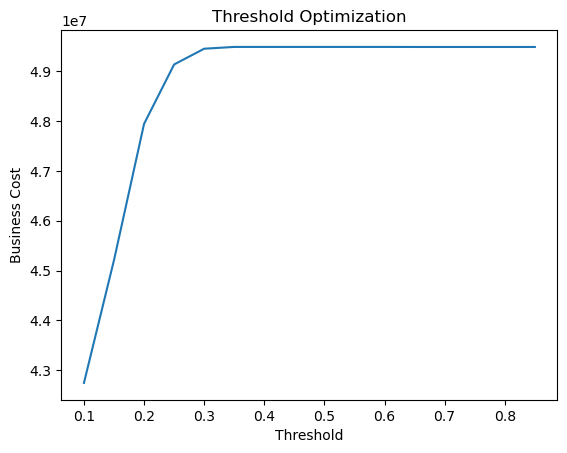

In [22]:
plt.plot(thresholds, costs)
plt.xlabel("Threshold")
plt.ylabel("Business Cost")
plt.title("Threshold Optimization")
plt.show()

In [23]:
y_pred_best = (y_pred_prob >= best_threshold).astype(int)

print(confusion_matrix(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best))

[[40181 16373]
 [ 2637  2312]]
              precision    recall  f1-score   support

         0.0       0.94      0.71      0.81     56554
         1.0       0.12      0.47      0.20      4949

    accuracy                           0.69     61503
   macro avg       0.53      0.59      0.50     61503
weighted avg       0.87      0.69      0.76     61503



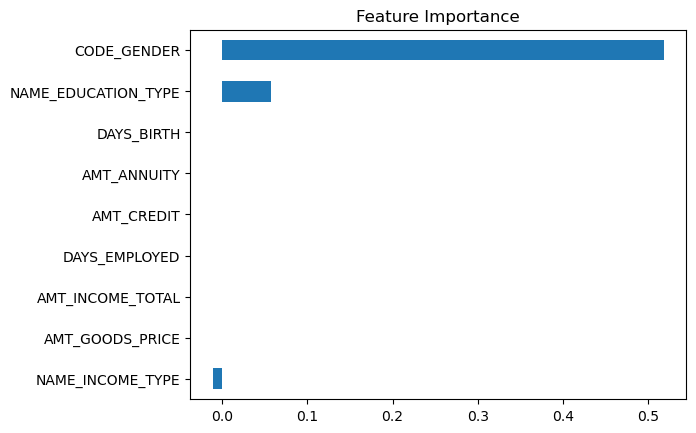

In [24]:
importance = pd.Series(model.coef_[0], index=X.columns)
importance.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()